# Artificial Neural Networks
## Assignment #1
### 22P-9277
### Saad Karim
### Task 0:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

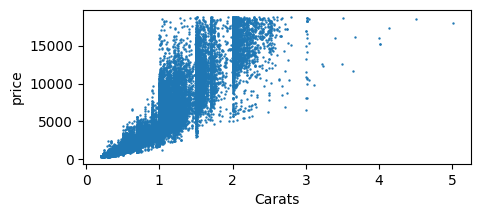

In [2]:
points = np.genfromtxt('diamonds.csv', delimiter=',')
points = points[1:len(points)]
carat = points[:,0]
cut = points[:,1]
color = points[:,2]
clarity = points[:,3]
depth = points[:,4]
table = points[:,5]
price = points[:,6]
xlen = points[:,7]
ylen = points[:,8]
zlen = points[:,9]
x = carat
y = price
plt.figure(figsize=(5,2))
plt.scatter(x,y,s=0.5)
plt.xlabel('Carats')
plt.ylabel('price')
plt.show()

Q1:The most suitable columns for a linear relationship are Carats (strongest) and possibly x, y, z (but redundant with Carats). For a multilinear relationship, use Carats, Cut, Color, Clarity, Depth, Table together, excluding x, y, z to avoid multicollinearity. For a polynomial relationship, Carats (or x, y, z) is best, likely with a quadratic or cubic model to capture non-linear price growth.


Q2:Vertical lines appear in plots of Cut, Color, or Clarity vs. Price because these features are ordinal, with discrete values (e.g., 1, 2, 3), causing prices to align vertically at each value. Horizontal lines are unlikely but could arise from repeated price values or data anomalies across continuous features like Carats or Depth.

### Task 1: Relationship between Learning Rate and Iterations

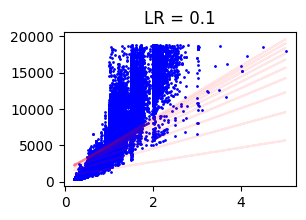

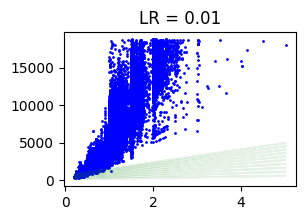

In [4]:
for learning_rate, color, num_iterations in zip([0.1, 0.01], ['r', 'g'], [10, 10]):
    b = 0
    m = 0
    plt.figure(figsize=(3,2))
    plt.scatter(x, y, s=1, c='b')
    plt.title(f'LR = {learning_rate}')
    for i in range(num_iterations):
        i = i+1
        m_gradient = 0
        b_gradient = 0
        N = float(len(points))
        for j in range(0, len(points)):
            m_gradient += (2/N) * x[j] * (y[j] - (m * x[j] + b))
            b_gradient += (2/N) * (y[j] - (m * x[j] + b))

        m = m + learning_rate * m_gradient
        b = b + learning_rate * b_gradient
        pred = m * x + b
        plt.plot(x, pred, c=color, alpha=0.1)
    plt.show()

Q1:Approximately 100 iterations are needed for LR = 0.01 to make its linear regression line similar to LR = 0.1 after 10 iterations. This is because LR = 0.01 takes steps 10 times smaller, requiring roughly 10 times more iterations to converge to a similar point.

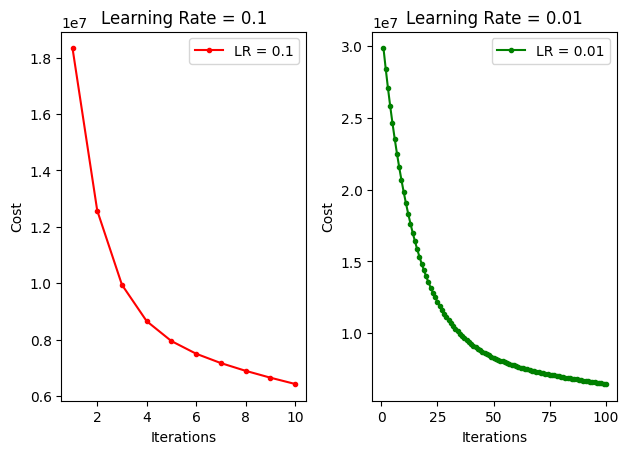

LR = 0.1, Iteration 1, Cost: 18331180.950739276
LR = 0.1, Iteration 2, Cost: 12572840.324531643
LR = 0.1, Iteration 3, Cost: 9939901.75332056
LR = 0.1, Iteration 4, Cost: 8651243.207917139
LR = 0.1, Iteration 5, Cost: 7945361.173647724
LR = 0.1, Iteration 6, Cost: 7496445.413102281
LR = 0.1, Iteration 7, Cost: 7164873.912027172
LR = 0.1, Iteration 8, Cost: 6890601.399416669
LR = 0.1, Iteration 9, Cost: 6647604.541775355
LR = 0.1, Iteration 10, Cost: 6424415.936567521
Minimum cost for LR = 0.1: 6424415.936567521
LR = 0.01, Iteration 1, Cost: 29837304.246570334
LR = 0.01, Iteration 2, Cost: 28395300.853477668
LR = 0.01, Iteration 3, Cost: 27049242.5794254
LR = 0.01, Iteration 4, Cost: 25792610.248311736
LR = 0.01, Iteration 5, Cost: 24619328.359842334
LR = 0.01, Iteration 6, Cost: 23523734.89054237
LR = 0.01, Iteration 7, Cost: 22500553.150295265
LR = 0.01, Iteration 8, Cost: 21544865.554496165
LR = 0.01, Iteration 9, Cost: 20652089.181432232
LR = 0.01, Iteration 10, Cost: 19817952.99337

In [3]:
#Q2, part a
for idx, (learning_rate, color, num_iterations) in enumerate(zip([0.1, 0.01], ['r', 'g'], [10, 100])):
    b = 0
    m = 0
    costs = []

    for i in range(num_iterations):
        m_gradient = 0
        b_gradient = 0
        N = float(len(points))
        for j in range(0, len(points)):
            m_gradient += (2 / N) * x[j] * (y[j] - (m * x[j] + b))
            b_gradient += (2 / N) * (y[j] - (m * x[j] + b))
        m = m + learning_rate * m_gradient
        b = b + learning_rate * b_gradient
        cost = np.sum((y - (m * x + b)) ** 2) / N
        costs.append(cost)

    plt.subplot(1, 2, idx + 1)
    plt.plot(range(1, num_iterations + 1), costs, marker='.', color=color, label=f'LR = {learning_rate}')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.title(f'Learning Rate = {learning_rate}')
    plt.legend()

plt.tight_layout()
plt.show()
# Q2, part b
for learning_rate, num_iterations in zip([0.1, 0.01], [10, 100]):
    b = 0
    m = 0
    costs = []  # To store cost for each iteration

    for i in range(num_iterations):
        m_gradient = 0
        b_gradient = 0
        N = float(len(points))
        # Compute gradients
        for j in range(0, len(points)):
            m_gradient += (2 / N) * x[j] * (y[j] - (m * x[j] + b))
            b_gradient += (2 / N) * (y[j] - (m * x[j] + b))
        m = m + learning_rate * m_gradient
        b = b + learning_rate * b_gradient

        # Compute cost (MSE)
        cost = np.sum((y - (m * x + b)) ** 2) / N
        costs.append(cost)
        print(f'LR = {learning_rate}, Iteration {i+1}, Cost: {cost}')

    print(f'Minimum cost for LR = {learning_rate}: {min(costs)}')

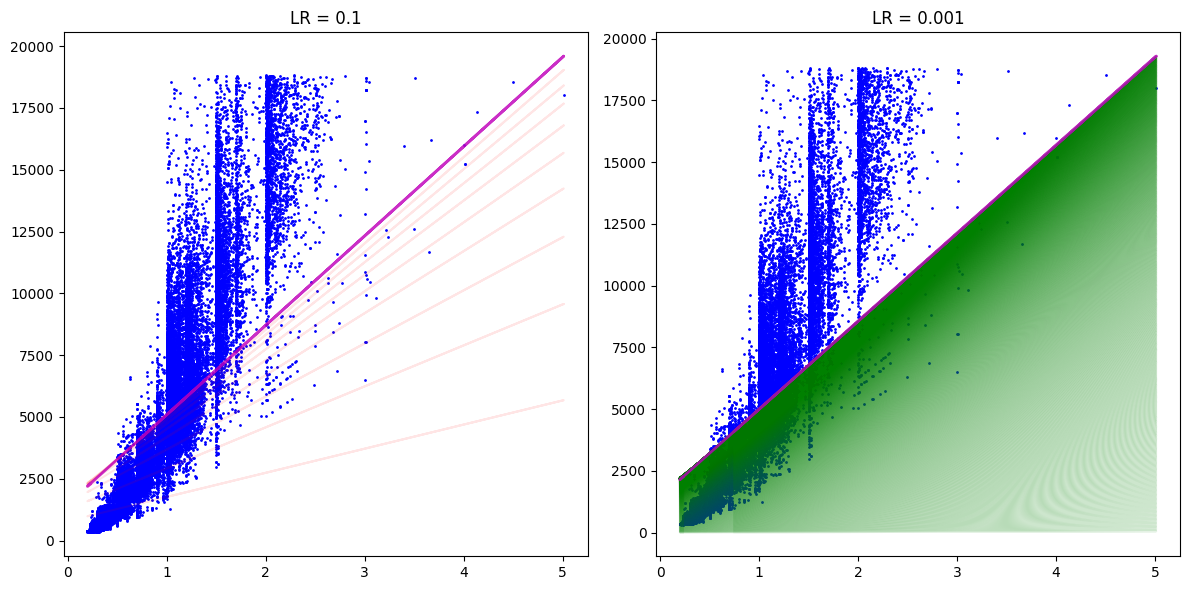

In [5]:
# Q3, and last part
learning_rates = [0.1, 0.001]
colors = ['r', 'g']

plt.figure(figsize=(12, 6))

for idx, (learning_rate, color, num_iterations) in enumerate(zip(learning_rates, colors, [10, 1000])):
    b = 0
    m = 0
    plt.subplot(1, 2, idx + 1)
    plt.scatter(x, y, s=1, c='b')
    for i in range(num_iterations):
        m_gradient = 0
        b_gradient = 0
        N = float(len(points))
        for j in range(0, len(points)):
            m_gradient += (2 / N) * x[j] * (y[j] - (m * x[j] + b))
            b_gradient += (2 / N) * (y[j] - (m * x[j] + b))

        m = m + learning_rate * m_gradient
        b = b + learning_rate * b_gradient
        pred = m * x + b
        plt.plot(x, pred, c=color, alpha=0.1)

    plt.plot(x, pred, c='m', alpha=0.8, linewidth=2)
    plt.title(f'LR = {learning_rate}')

plt.tight_layout()
plt.show()


Would you be willing to try a learning rate of 0.0001?

Yes, I would be willing to try a learning rate of 0.0001.  However, to get a similar result, you would need to increase the number of iterations even further (e.g., to 10,000 or more).  Very small learning rates require many more iterations to converge.

Q2(3): The regression line's behavior depends on the learning rate.  Higher rates (like 0.1) cause more oscillation, with erratic early adjustments. Lower rates (like 0.001) produce smoother, more gradual progression towards the best fit.  The line "explores" more with higher rates and "refines" more with lower ones.

### Task 2: Converting to Stochastic Gradient Descent

In [8]:
for j in range(0, len(points)):
    m_gradient += (2/len(points)) * x[j] * (y[j] - (m * x[j] + b))
m = m + learning_rate * m_gradient
idx = np.random.randint(0, len(points))
x_j, y_j = x[idx], y[idx]
m_gradient += 2 * x_j * (y_j - (m * x_j + b))
m = m + learning_rate * m_gradient

idx = np.random.randint(0, len(points))
x_j, y_j = x[idx], y[idx]
m_gradient += 2 * x_j * (y_j - (m * x_j + b))
m = m + learning_rate * m_gradient

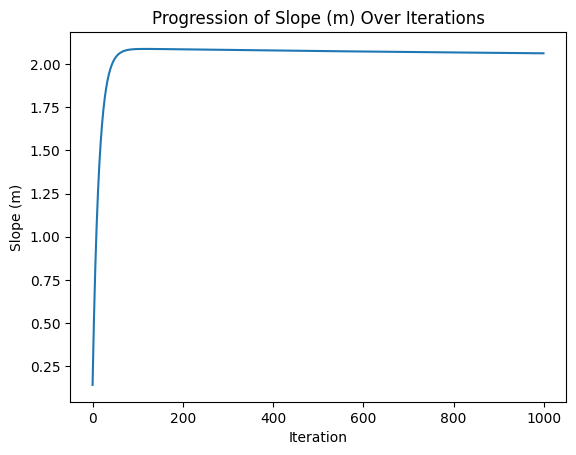

In [12]:
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 2 * x + 1 + np.random.normal(0, 1, 100)  # y = 2x + 1 + noise

m = 0.0
b = 0.0 
learning_rate = 0.001
epochs = 1000
m_history = []

for epoch in range(epochs):
    m_gradient = 0.0
    b_gradient = 0.0
    for j in range(len(x)):
        x_j, y_j = x[j], y[j]
        y_pred = m * x_j + b
        error = y_j - y_pred
        m_gradient += (2 / len(x)) * x_j * error
        b_gradient += (2 / len(x)) * error
    
    # Update parameters
    m += learning_rate * m_gradient
    b += learning_rate * b_gradient
    m_history.append(m)

plt.plot(m_history)
plt.xlabel("Iteration")
plt.ylabel("Slope (m)")
plt.title("Progression of Slope (m) Over Iterations")
plt.show()

## Q 1: The linear regression line exhibits oscillation.

Q2 + Q3

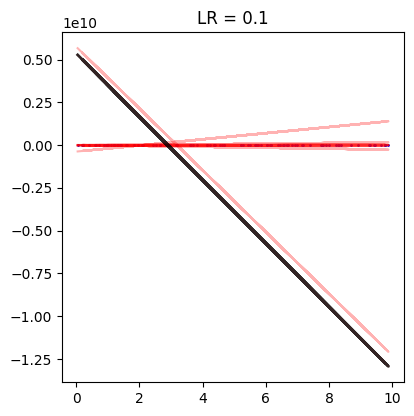

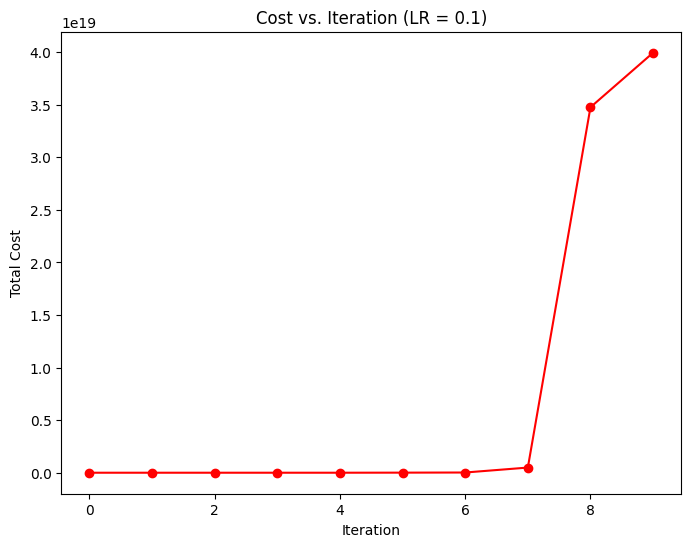

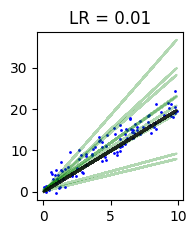

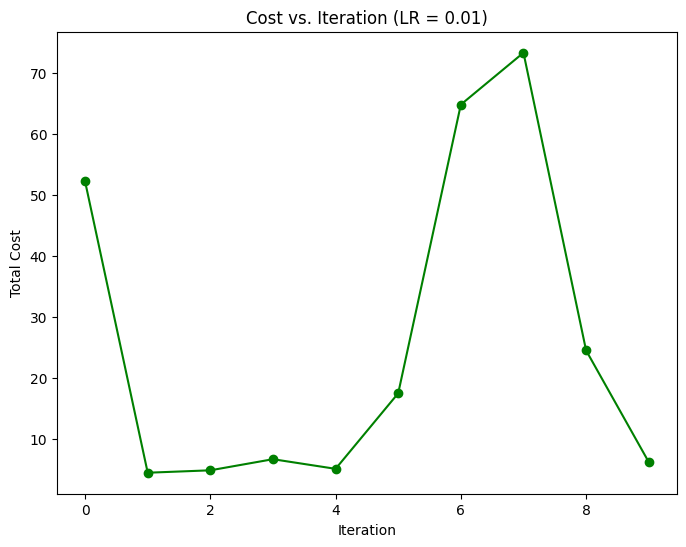

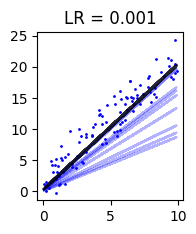

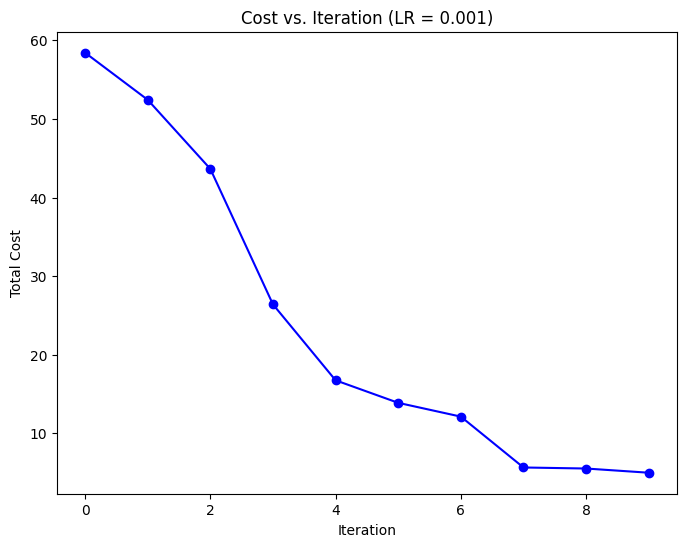

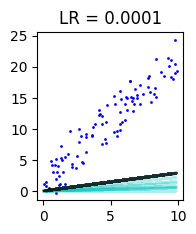

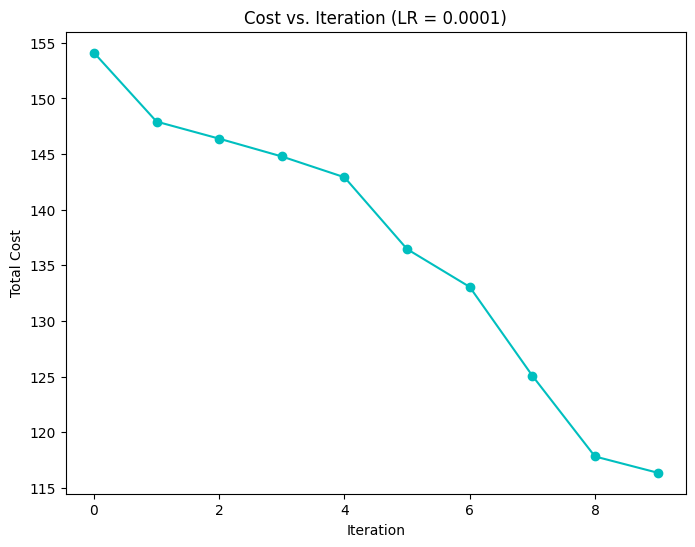

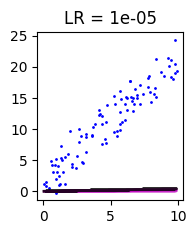

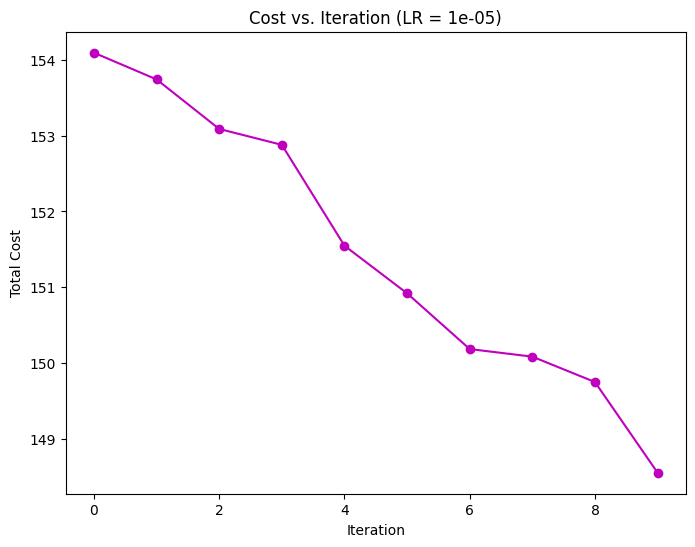

<Figure size 640x480 with 0 Axes>

In [16]:
np.random.seed(0)
x = np.random.rand(100) * 10
y = 2 * x + 1 + np.random.randn(100) * 2
points = np.array(list(zip(x, y)))
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]
colors = ['r', 'g', 'b', 'c', 'm']

plt.figure(figsize=(15, 10))

for idx, (learning_rate, color) in enumerate(zip(learning_rates, colors)):
    b = 0
    m = 0
    plt.subplot(2, 3, idx + 1)
    plt.scatter(x, y, s=1, c='b')
    plt.title(f'LR = {learning_rate}')
    cost_graph = []
    for i in range(10):
        m_gradient = 0
        b_gradient = 0
        N = float(len(points))

        idx1 = np.random.randint(0, len(points))
        x_j1, y_j1 = x[idx1], y[idx1]
        m_gradient += 2 * x_j1 * (y_j1 - (m * x_j1 + b))
        m = m + learning_rate * m_gradient

        idx2 = np.random.randint(0, len(points))
        x_j2, y_j2 = x[idx2], y[idx2]
        m_gradient += 2 * x_j2 * (y_j2 - (m * x_j2 + b))
        m = m + learning_rate * m_gradient
        
        b_gradient = 0
        idx1 = np.random.randint(0, len(points))
        x_j1, y_j1 = x[idx1], y[idx1]
        b_gradient +=  2 * (y_j1 - (m * x_j1 + b))
        b = b + learning_rate * b_gradient

        idx2 = np.random.randint(0, len(points))
        x_j2, y_j2 = x[idx2], y[idx2]
        b_gradient +=  2 * (y_j2 - (m * x_j2 + b))
        b = b + learning_rate * b_gradient
        
        pred = m * x + b
        plt.plot(x, pred, c=color, alpha=0.3) 
        
        total_cost = np.mean((y - (m * x + b)) ** 2)
        cost_graph.append(total_cost)

    plt.plot(x, pred, c='k', alpha=0.8, linewidth=2)
    plt.figure(figsize=(8, 6))
    plt.plot(range(10), cost_graph, marker='o', color=color)
    plt.xlabel('Iteration')
    plt.ylabel('Total Cost')
    plt.title(f'Cost vs. Iteration (LR = {learning_rate})')
    plt.show()

plt.tight_layout()
plt.show()


Q4: Stochastic Gradient Descent (SGD) uses single random data points for updates, causing noisy gradient estimates.  These noisy updates make the parameters, and thus the cost, oscillate.  The oscillations arise from the inherent randomness in how SGD samples data.

### Task 3: Fitting to Polynomial Regression

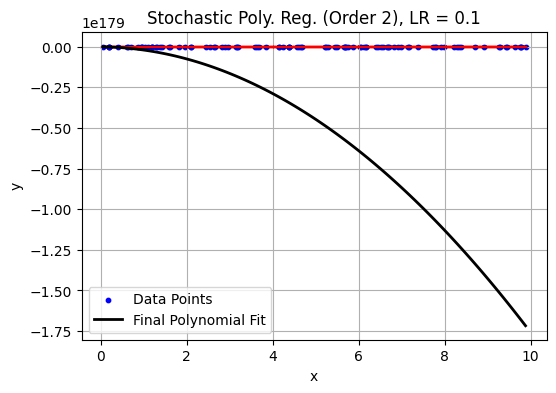

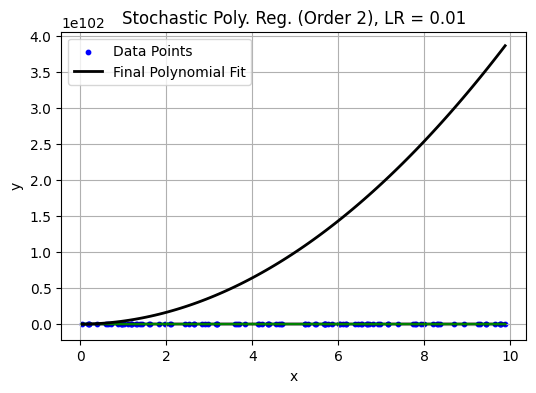

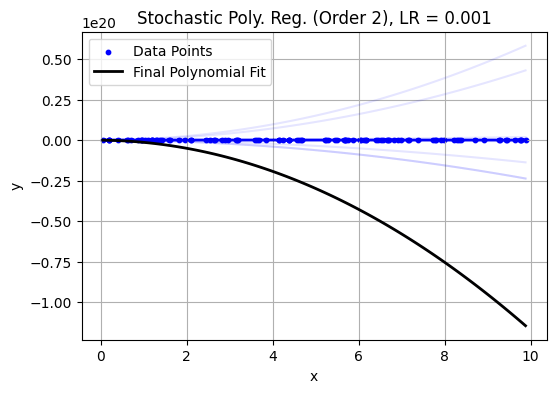

In [17]:
np.random.seed(0)
x = np.random.rand(100) * 10
y = 2 * x**2 + 3 * x + 1 + np.random.randn(100) * 10
points = np.array(list(zip(x, y)))

for learning_rate, color, num_iterations in zip([0.1, 0.01, 0.001], ['r', 'g', 'b'], [100, 100, 100]):
    c0 = 0
    c1 = 0
    c2 = 0 
    plt.figure(figsize=(6, 4)) 
    plt.scatter(x, y, s=10, c='b', label='Data Points')
    plt.title(f'Stochastic Poly. Reg. (Order 2), LR = {learning_rate}')
    plt.xlabel('x')
    plt.ylabel('y')

    for i in range(num_iterations):
        c0_gradient = 0
        c1_gradient = 0
        c2_gradient = 0
        N = float(len(points))

        idx = np.random.randint(0, len(points))
        x_j, y_j = x[idx], y[idx]

        c0_gradient = 2 * (y_j - (c0 + c1 * x_j + c2 * x_j**2))
        c1_gradient = 2 * x_j * (y_j - (c0 + c1 * x_j + c2 * x_j**2))
        c2_gradient = 2 * x_j**2 * (y_j - (c0 + c1 * x_j + c2 * x_j**2))

        c0 = c0 + learning_rate * c0_gradient
        c1 = c1 + learning_rate * c1_gradient
        c2 = c2 + learning_rate * c2_gradient

        x_new = np.linspace(min(x), max(x), 100)  
        pred = c0 + c1 * x_new + c2 * x_new**2
        plt.plot(x_new, pred, c=color, alpha=0.1)

    # Plot the final polynomial curve
    x_new = np.linspace(min(x), max(x), 100)
    pred = c0 + c1 * x_new + c2 * x_new**2
    plt.plot(x_new, pred, c='k', linewidth=2, label='Final Polynomial Fit')
    plt.legend()
    plt.grid(True)
    plt.show()


Q1

C:\Users\CL\AppData\Local\Temp\ipykernel_5172\2460125361.py:40: RuntimeWarning: overflow encountered in square
  error = np.mean((y - (c0 + c1 * x + c2 * x**2))**2)


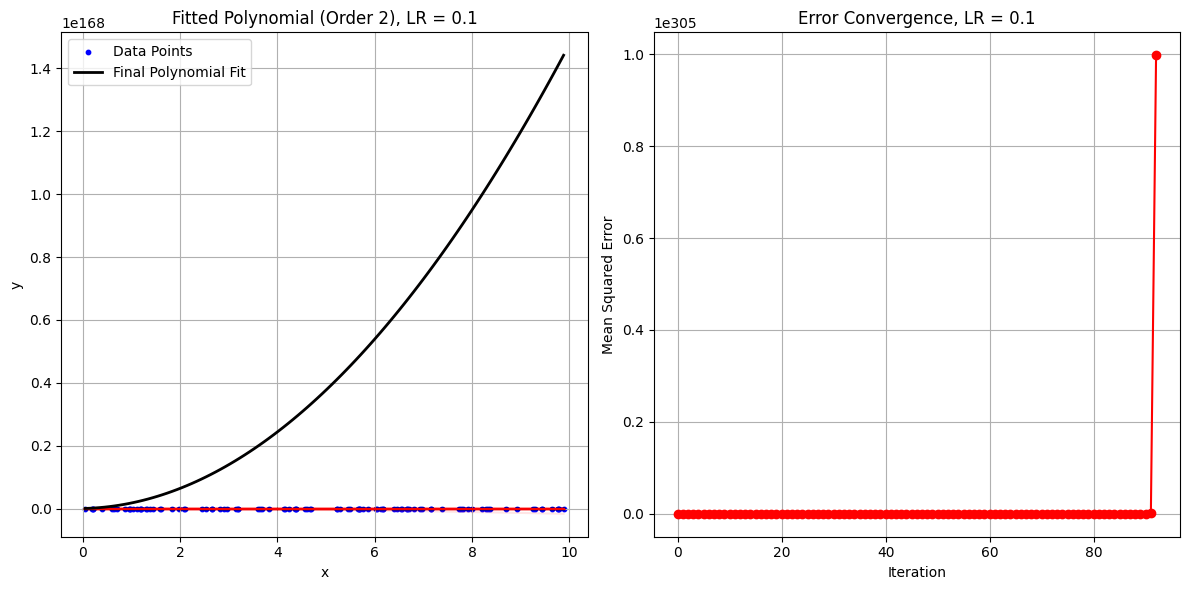

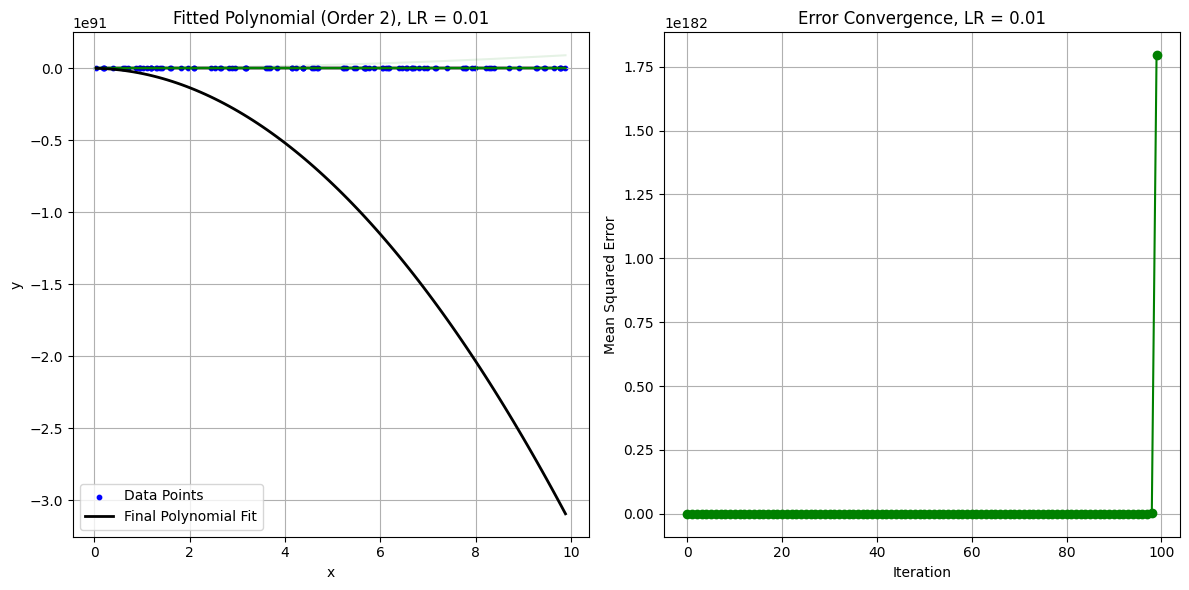

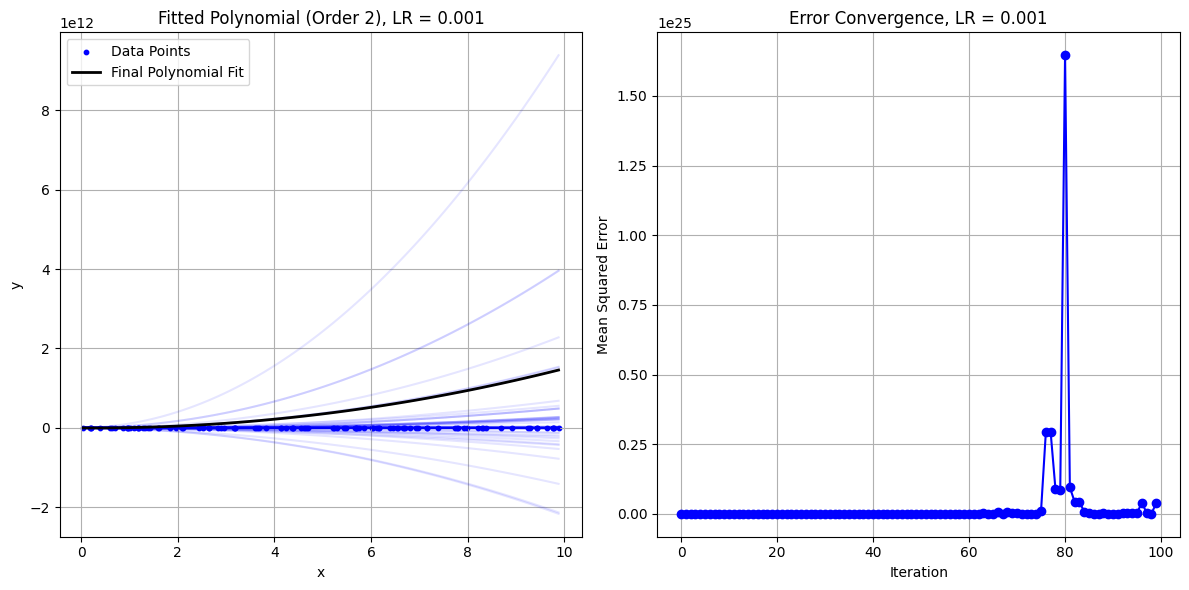

In [ ]:
for learning_rate, color, num_iterations in zip([0.1, 0.01, 0.001], ['r', 'g', 'b'], [100, 100, 100]):
    c0 = 0
    c1 = 0
    c2 = 0  
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.scatter(x, y, s=10, c='b', label='Data Points')
    plt.title(f'Fitted Polynomial (Order 2), LR = {learning_rate}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    errors = []
    for i in range(num_iterations):
        c0_gradient = 0
        c1_gradient = 0
        c2_gradient = 0
        N = float(len(points))

        idx = np.random.randint(0, len(points))
        x_j, y_j = x[idx], y[idx]

        c0_gradient = 2 * (y_j - (c0 + c1 * x_j + c2 * x_j**2))
        c1_gradient = 2 * x_j * (y_j - (c0 + c1 * x_j + c2 * x_j**2))
        c2_gradient = 2 * x_j**2 * (y_j - (c0 + c1 * x_j + c2 * x_j**2))

        c0 = c0 + learning_rate * c0_gradient
        c1 = c1 + learning_rate * c1_gradient
        c2 = c2 + learning_rate * c2_gradient

        x_new = np.linspace(min(x), max(x), 100)
        pred = c0 + c1 * x_new + c2 * x_new**2
        plt.plot(x_new, pred, c=color, alpha=0.1)
        
        error = np.mean((y - (c0 + c1 * x + c2 * x**2))**2)
        errors.append(error)

    x_new = np.linspace(min(x), max(x), 100)
    pred = c0 + c1 * x_new + c2 * x_new**2
    plt.plot(x_new, pred, c='k', linewidth=2, label='Final Polynomial Fit')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(num_iterations), errors, c=color, marker='o')
    plt.title(f'Error Convergence, LR = {learning_rate}')
    plt.xlabel('Iteration')
    plt.ylabel('Mean Squared Error')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Q2

c:\Users\CL\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\CL\AppData\Local\Temp\ipykernel_5172\4067229710.py:40: RuntimeWarning: overflow encountered in square
  error = np.mean((y - (c0 + c1 * x + c2 * x**2 + c3 * x**3))**2)


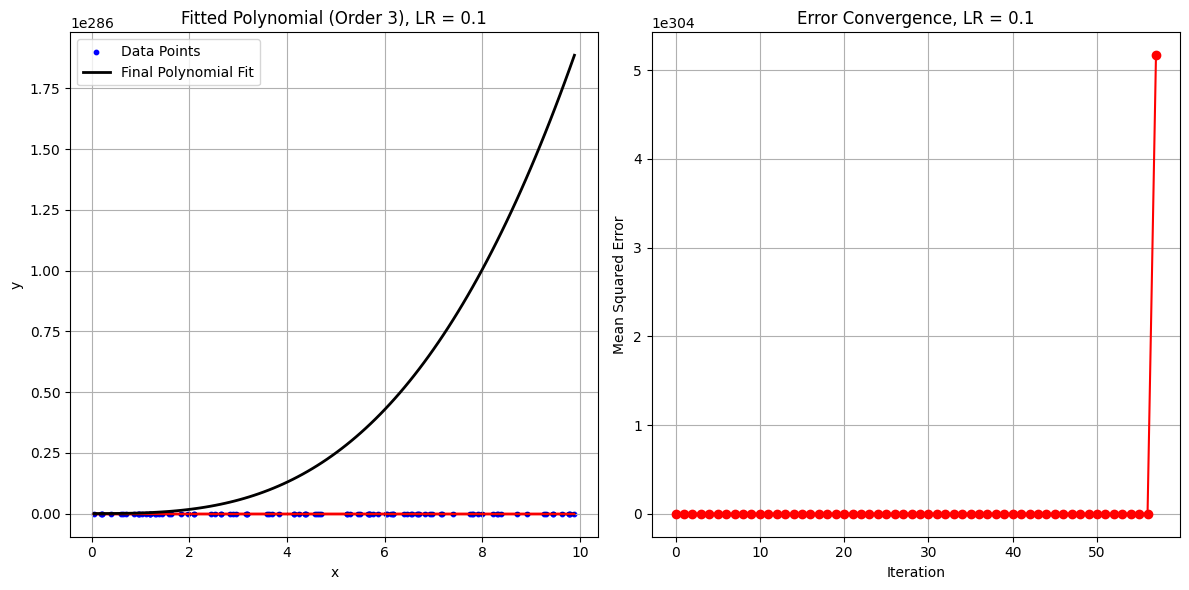

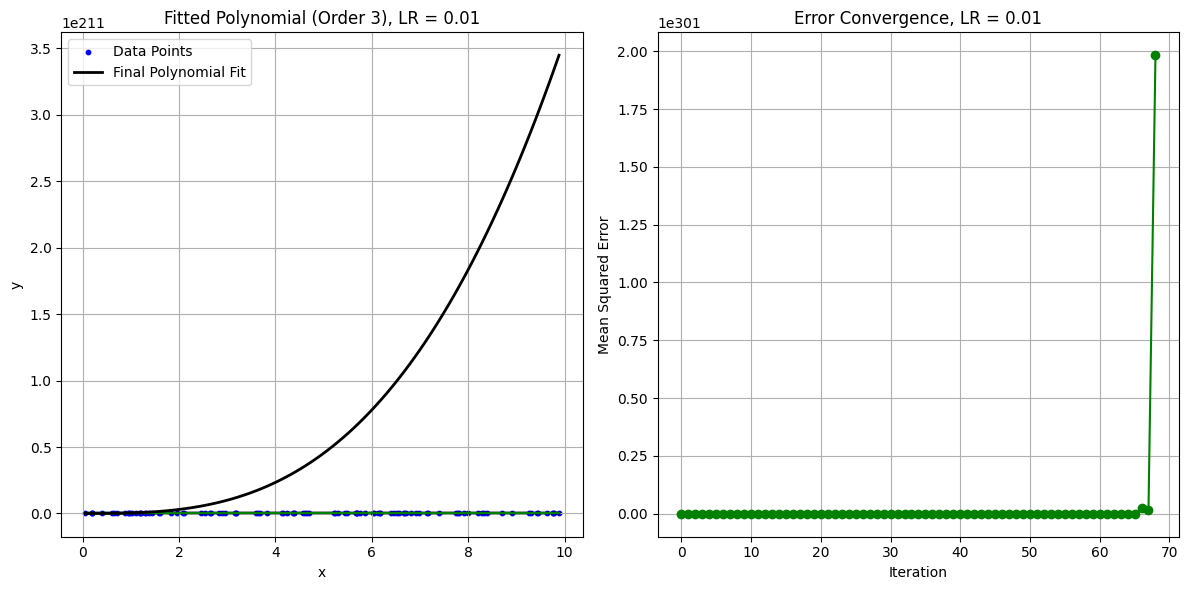

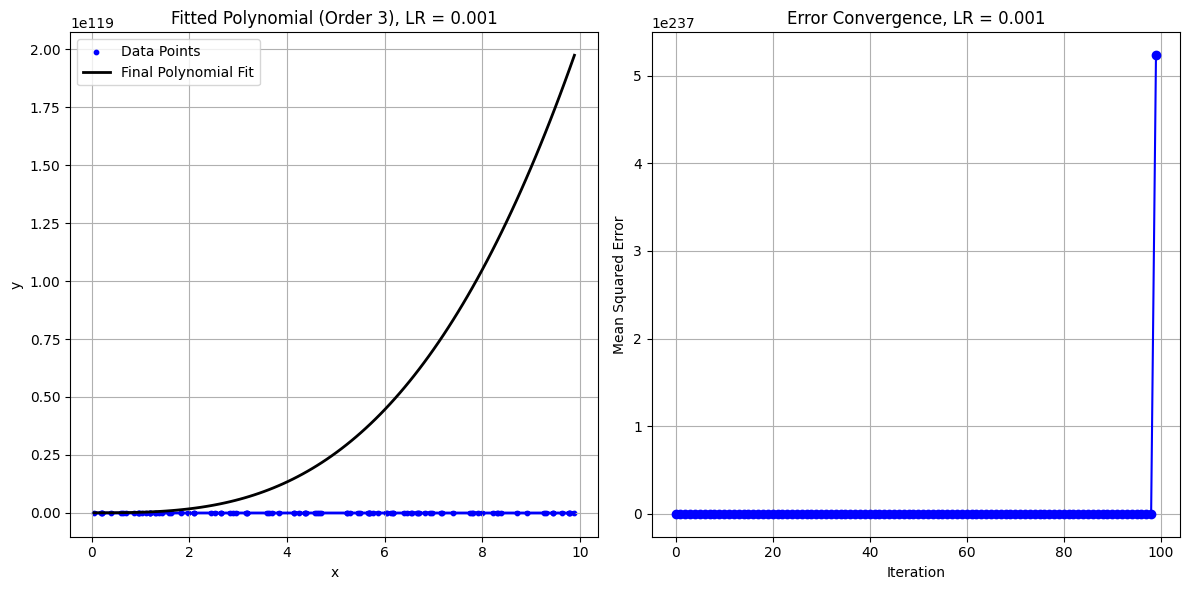

In [ ]:
# Polynomial regression with stochastic gradient descent (order 3)
for learning_rate, color, num_iterations in zip([0.1, 0.01, 0.001], ['r', 'g', 'b'], [100, 100, 100]):
    c0 = 0
    c1 = 0
    c2 = 0 
    c3 = 0 
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.scatter(x, y, s=10, c='b', label='Data Points')
    plt.title(f'Fitted Polynomial (Order 3), LR = {learning_rate}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    errors = []
    for i in range(num_iterations):
        c0_gradient = 0
        c1_gradient = 0
        c2_gradient = 0
        c3_gradient = 0
        N = float(len(points))
        idx = np.random.randint(0, len(points))
        x_j, y_j = x[idx], y[idx]

        c0_gradient = 2 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3))
        c1_gradient = 2 * x_j * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3))
        c2_gradient = 2 * x_j**2 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3))
        c3_gradient = 2 * x_j**3 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3))

        c0 = c0 + learning_rate * c0_gradient
        c1 = c1 + learning_rate * c1_gradient
        c2 = c2 + learning_rate * c2_gradient
        c3 = c3 + learning_rate * c3_gradient

        x_new = np.linspace(min(x), max(x), 100) 
        pred = c0 + c1 * x_new + c2 * x_new**2 + c3 * x_new**3
        plt.plot(x_new, pred, c=color, alpha=0.1) 
        
        error = np.mean((y - (c0 + c1 * x + c2 * x**2 + c3 * x**3))**2)
        errors.append(error)

    x_new = np.linspace(min(x), max(x), 100)
    pred = c0 + c1 * x_new + c2 * x_new**2 + c3 * x_new**3
    plt.plot(x_new, pred, c='k', linewidth=2, label='Final Polynomial Fit')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(num_iterations), errors, c=color, marker='o')
    plt.title(f'Error Convergence, LR = {learning_rate}')
    plt.xlabel('Iteration')
    plt.ylabel('Mean Squared Error')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Q3

C:\Users\CL\AppData\Local\Temp\ipykernel_5172\669991342.py:46: RuntimeWarning: overflow encountered in square
  error = np.mean((y - (c0 + c1 * x + c2 * x**2 + c3 * x**3 + c4 * x**4))**2)
C:\Users\CL\AppData\Local\Temp\ipykernel_5172\669991342.py:33: RuntimeWarning: overflow encountered in scalar multiply
  c3_gradient = 2 * x_j**3 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3 + c4 * x_j**4))
C:\Users\CL\AppData\Local\Temp\ipykernel_5172\669991342.py:34: RuntimeWarning: overflow encountered in scalar multiply
  c4_gradient = 2 * x_j**4 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3 + c4 * x_j**4))
C:\Users\CL\AppData\Local\Temp\ipykernel_5172\669991342.py:43: RuntimeWarning: overflow encountered in multiply
  pred = c0 + c1 * x_new + c2 * x_new**2 + c3 * x_new**3 + c4 * x_new**4
C:\Users\CL\AppData\Local\Temp\ipykernel_5172\669991342.py:43: RuntimeWarning: overflow encountered in add
  pred = c0 + c1 * x_new + c2 * x_new**2 + c3 * x_new**3 + c4 * x_new**4
C:\Users\CL\AppData

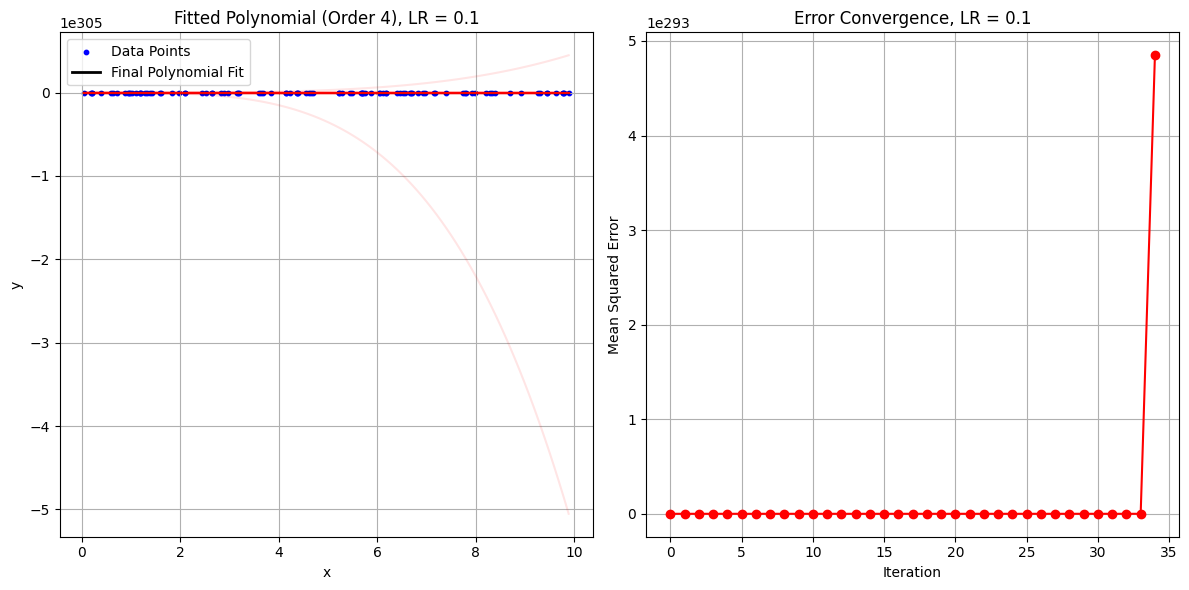

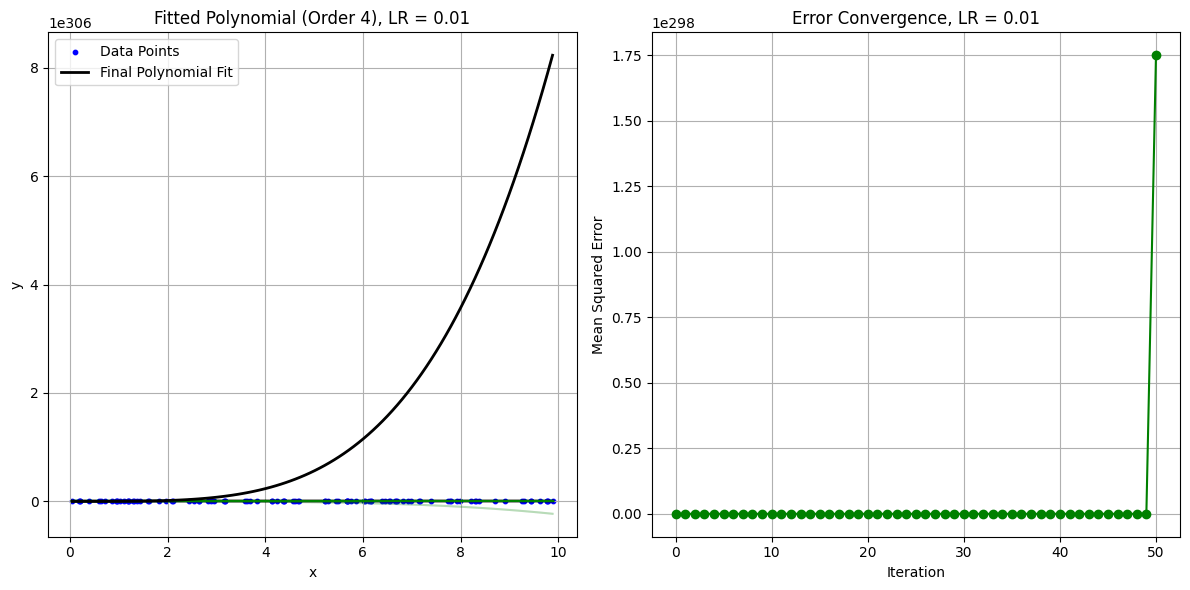

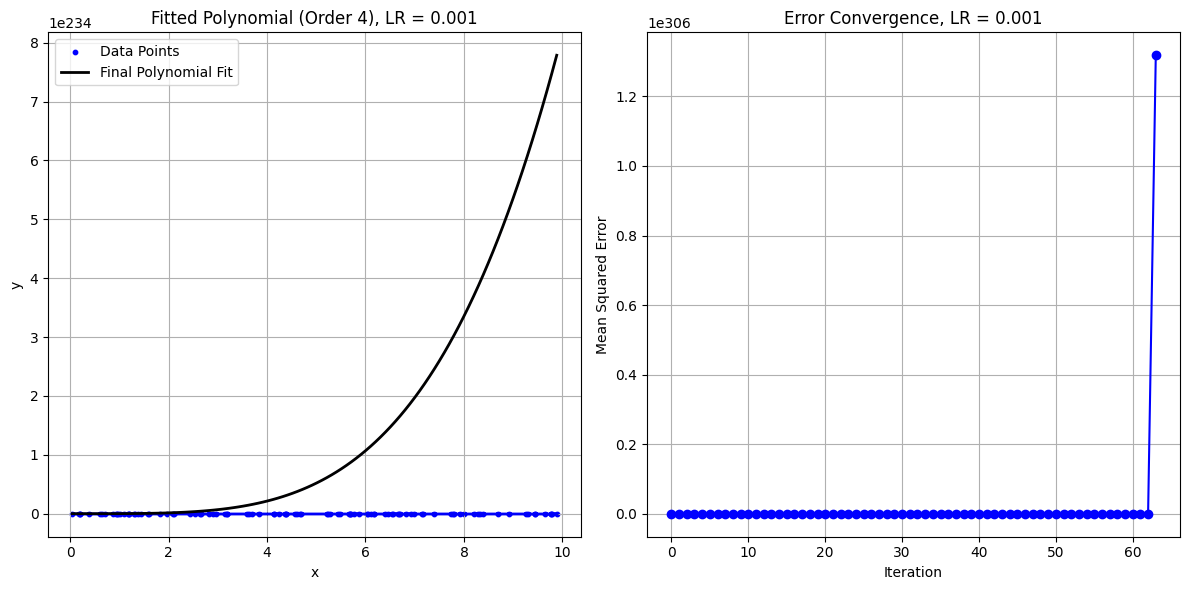

In [ ]:
# Polynomial regression with stochastic gradient descent (order 4)
for learning_rate, color, num_iterations in zip([0.1, 0.01, 0.001], ['r', 'g', 'b'], [100, 100, 100]):
    c0 = 0
    c1 = 0
    c2 = 0  
    c3 = 0  
    c4 = 0 
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.scatter(x, y, s=10, c='b', label='Data Points')
    plt.title(f'Fitted Polynomial (Order 4), LR = {learning_rate}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    errors = []
    for i in range(num_iterations):
        c0_gradient = 0
        c1_gradient = 0
        c2_gradient = 0
        c3_gradient = 0
        c4_gradient = 0
        N = float(len(points))

        idx = np.random.randint(0, len(points))
        x_j, y_j = x[idx], y[idx]

        c0_gradient = 2 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3 + c4 * x_j**4))
        c1_gradient = 2 * x_j * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3 + c4 * x_j**4))
        c2_gradient = 2 * x_j**2 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3 + c4 * x_j**4))
        c3_gradient = 2 * x_j**3 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3 + c4 * x_j**4))
        c4_gradient = 2 * x_j**4 * (y_j - (c0 + c1 * x_j + c2 * x_j**2 + c3 * x_j**3 + c4 * x_j**4))

        c0 = c0 + learning_rate * c0_gradient
        c1 = c1 + learning_rate * c1_gradient
        c2 = c2 + learning_rate * c2_gradient
        c3 = c3 + learning_rate * c3_gradient
        c4 = c4 + learning_rate * c4_gradient

        x_new = np.linspace(min(x), max(x), 100)
        pred = c0 + c1 * x_new + c2 * x_new**2 + c3 * x_new**3 + c4 * x_new**4
        plt.plot(x_new, pred, c=color, alpha=0.1)
        
        error = np.mean((y - (c0 + c1 * x + c2 * x**2 + c3 * x**3 + c4 * x**4))**2)
        errors.append(error)

    x_new = np.linspace(min(x), max(x), 100)
    pred = c0 + c1 * x_new + c2 * x_new**2 + c3 * x_new**3 + c4 * x_new**4
    plt.plot(x_new, pred, c='k', linewidth=2, label='Final Polynomial Fit')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(num_iterations), errors, c=color, marker='o')
    plt.title(f'Error Convergence, LR = {learning_rate}')
    plt.xlabel('Iteration')
    plt.ylabel('Mean Squared Error')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
